# Results: detecting ERD/ERS events with YOLO and Faster R-CNN

This notebook collects the results of experiments E1–E5 on BCI Competition IV dataset 2a. Each image is the
session-level z map of the mean Morlet power of **5 trials** with the same cue (see `annotation.ipynb` for why
single trials cannot be labeled reliably). Boxes are generated automatically and their class is the panel of
the event (`ERD_C4`, `ERD_C3`, `ERD_Cz`, `ERD_lateral` for C5/C6, `ERS_rebound` after 4 s).

All metrics come from one evaluator (`src/evaluate.py`, torchmetrics `MeanAveragePrecision`, COCO IoUs) and are
read from `results/tables/`. Validation is session T (pool of 20 % of the trials), test is session E
(cross-session). Model selection uses validation only.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.evaluate import decode_groups, load_predictions
from src.utils.coords import MI_CLASSES
from src.utils.io import load_config, resolve
from src.utils.viz import plot_confusions, plot_e4, plot_pipeline, plot_training_curves

T, F = resolve("results/tables"), resolve("results/figures")
pd.set_option("display.precision", 3)

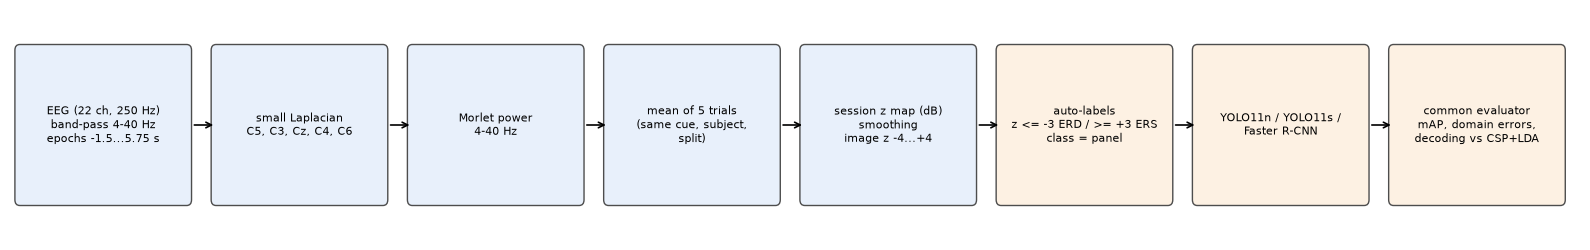

In [2]:
plot_pipeline(F / "pipeline.png")
plt.show()

## E1: training settings (YOLO11n, validation)

One factor changed at a time from the baseline (SGD, lr0 = 1e-2, batch 16, imgsz 640, 100 epochs, all
augmentation off).

In [3]:
e1 = pd.read_csv(T / "e1_hyperparams.csv")
e1

,run_id,change,map50,map50_95,precision,recall,f1,epochs_trained,train_time_min,notes,selected
0,e1_baseline,-,0.974,0.815,0.832,0.981,0.900,100.0,28.2,NaN,True
1,e1_lr1e-3,lr0 = 1e-3,0.954,0.791,0.868,0.935,0.900,77.0,34.1,NaN,False
2,e1_batch32,batch = 32,0.953,0.813,0.815,0.968,0.885,100.0,43.0,re-run with workers=1 after the first attempt ...,False
3,e1_imgsz512,imgsz = 512,0.958,0.748,0.828,0.981,0.898,80.0,22.6,NaN,False
4,e1_ep50,epochs = 50,0.973,0.790,0.835,0.981,0.902,50.0,16.9,NaN,False
5,e1_adamw,optimizer = AdamW (lr0 kept at 1e-2),0.956,0.773,0.838,0.955,0.893,93.0,28.1,NaN,False


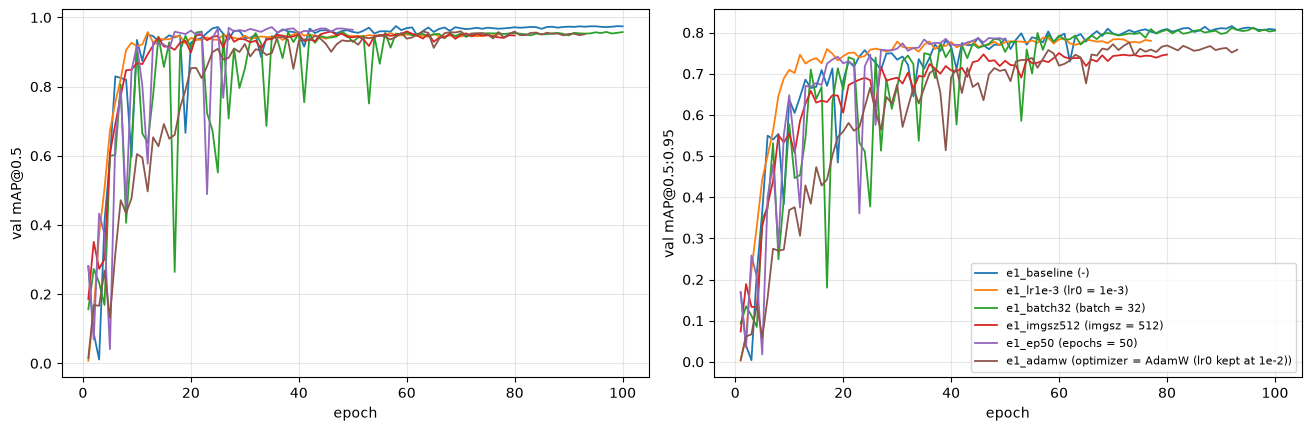

In [4]:
def ultra_curve(run):
    d = pd.read_csv(resolve("results/runs") / run / "results.csv")
    d.columns = [c.strip() for c in d.columns]
    return pd.DataFrame({"epoch": d["epoch"], "map50": d["metrics/mAP50(B)"], "map50_95": d["metrics/mAP50-95(B)"]})

curves = {f"{r} ({c})": ultra_curve(r) for r, c in zip(e1["run_id"], e1["change"])}
plot_training_curves(curves, F / "training_curves_e1.png")
plt.show()

Differences between settings are small (≈ 0.02 mAP@0.5) relative to what a 360-image validation set with
strongly overlapping groups can resolve. The clearest effect is the lower input resolution: `imgsz = 512` reduces
mAP@0.5:0.95 and the precision of the box boundaries. The baseline configuration was kept.

Training curves use Ultralytics' own validation (monitoring only); after the validation set was switched to
unpadded 640 × 640 images (`src/train.py`, `no_rect_val_trainer`) these values match the common evaluator.

## E2: architecture (test)

In [5]:
e2 = pd.read_csv(T / "e2_architecture.csv")
display(e2)
ap = pd.read_csv(T / "per_class_ap.csv")
ap = ap[(ap["split"] == "test") & ap["run_id"].isin(e2["run_id"])]
display(ap.pivot(index="run_id", columns="class_name", values="ap50").reindex(e2["run_id"]))
ap.pivot(index="run_id", columns="class_name", values="ap50_95").reindex(e2["run_id"])

,run_id,model,map50,map50_95,precision,recall,f1,onset_err_ms,offset_err_ms,flow_err_hz,fhigh_err_hz,train_time_min,val_map50,val_map50_95,selected
0,threshold,"Threshold (label rule, reference)",1.000,1.000,1.000,1.000,1.000,0.024,0.018,5.201e-04,7.890e-04,NaN,1.000,1.000,False
1,e1_baseline,YOLO11n (best E1),0.925,0.735,0.812,0.970,0.884,18.014,20.901,2.229e-01,3.135e-01,28.2,0.974,0.815,True
2,e2_yolo11s,YOLO11s,0.937,0.777,0.806,0.972,0.882,17.194,20.260,1.977e-01,2.615e-01,48.9,0.967,0.830,False
3,e2_frcnn,Faster R-CNN (ResNet50-FPN v2),0.837,0.596,0.695,0.885,0.779,31.831,32.377,3.042e-01,4.155e-01,113.6,0.933,0.679,False


class_name,ERD_C3,ERD_C4,ERD_Cz,ERD_lateral,ERS_rebound
run_id,,,,,
threshold,1.000,1.000,1.000,1.000,1.000
e1_baseline,0.975,0.965,0.923,0.801,0.960
e2_yolo11s,0.967,0.955,0.933,0.860,0.969
e2_frcnn,0.859,0.761,0.754,0.856,0.953


class_name,ERD_C3,ERD_C4,ERD_Cz,ERD_lateral,ERS_rebound
run_id,,,,,
threshold,1.000,1.000,1.000,1.000,1.000
e1_baseline,0.877,0.836,0.663,0.513,0.785
e2_yolo11s,0.884,0.852,0.698,0.643,0.811
e2_frcnn,0.671,0.584,0.485,0.555,0.685


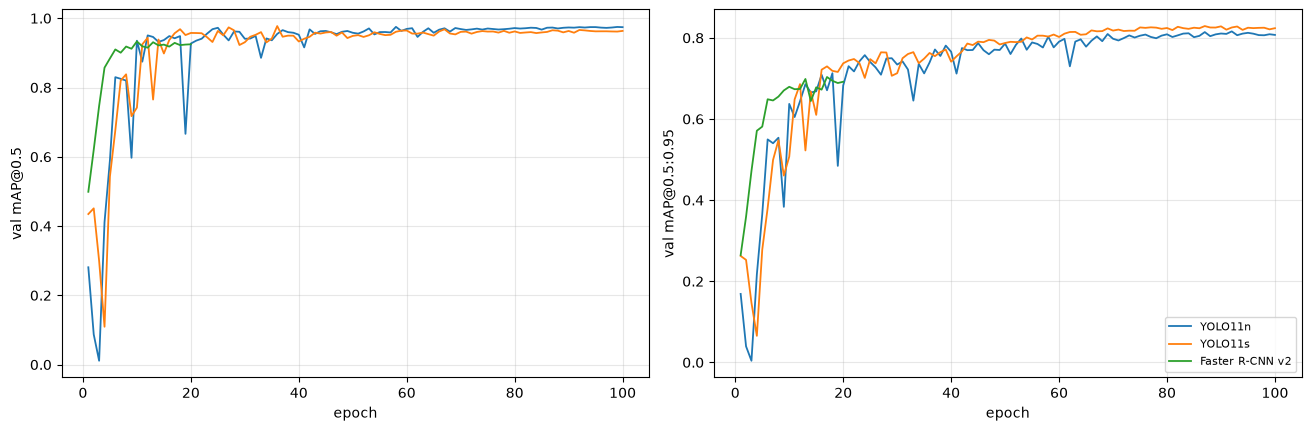

In [6]:
frcnn = pd.read_csv(resolve("results/runs/e2_frcnn/log.csv")).rename(columns={"val_map50": "map50", "val_map50_95": "map50_95"})
plot_training_curves({"YOLO11n": ultra_curve("e1_baseline"), "YOLO11s": ultra_curve("e2_yolo11s"),
                      "Faster R-CNN v2": frcnn}, F / "training_curves_e2.png")
plt.show()

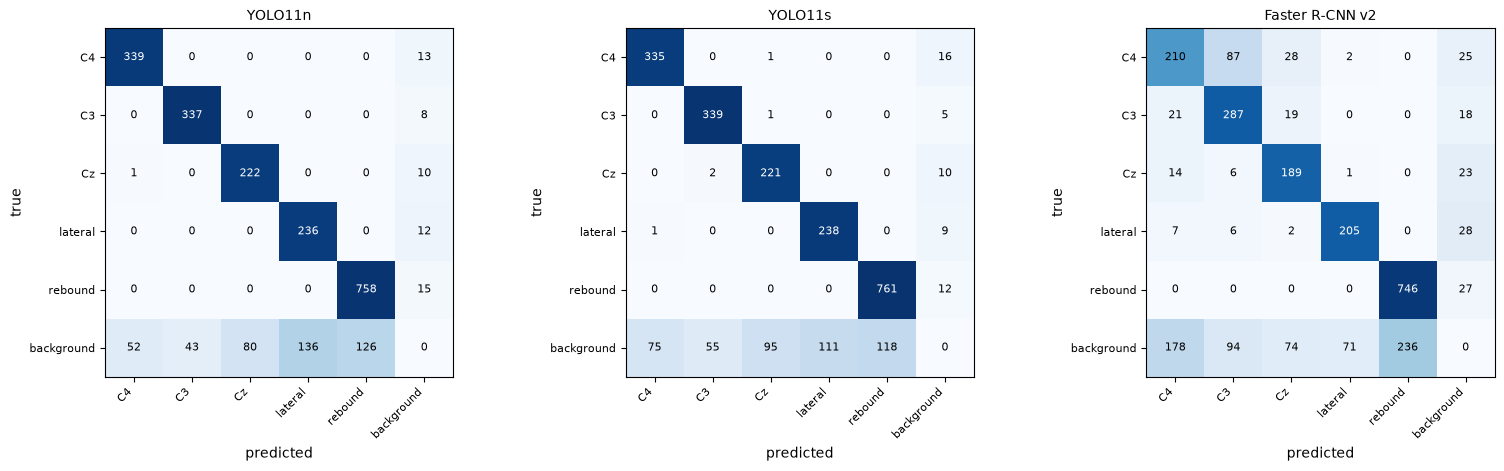

In [7]:
cms = {name: pd.read_csv(T / "confusion" / f"{run}_test.csv", index_col=0)
       for run, name in [("e1_baseline", "YOLO11n"), ("e2_yolo11s", "YOLO11s"), ("e2_frcnn", "Faster R-CNN v2")]}
plot_confusions(cms, F / "confusion_e2_test.png")
plt.show()

The threshold detector *is* the label generator, so its score of 1.0 is a reference, not a competitor. Among
the trained detectors, YOLO11n was selected on validation mAP@0.5; on the test session YOLO11s is slightly better,
and Faster R-CNN is clearly behind (its best validation epoch was 10 of 20). For both YOLO models the confusion
matrices show (almost) no swaps between classes: errors are false positives on background and a few missed boxes,
and `ERD_lateral` is the weakest class. Faster R-CNN, in contrast, often puts the right box on the right panel but
gives it the class of another panel (e.g. `ERD_C4` boxes labeled `ERD_C3`). A plausible reason: its second-stage
classifier only sees RoI-pooled features of the cropped region, which carry no absolute image position, while the
classes here are defined by vertical position; the YOLO heads predict classes directly on full-image feature maps,
where position is implicitly available.

### Variability across seeds (selected model)

In [8]:
pd.read_csv(T / "seed_runs.csv")

,split,run_id,seed,map50,map50_95,precision,recall,f1,onset_err_ms,offset_err_ms,decoding_acc
0,val,e1_baseline,0.0,0.974,0.815,0.835,0.981,0.902,11.760,10.899,0.144
1,val,e2_best_seed2,2.0,0.963,0.811,0.858,0.981,0.915,11.277,11.006,0.139
2,val,e2_best_seed1,1.0,0.960,0.800,0.843,0.958,0.897,9.062,9.266,0.139
3,val,mean,NaN,0.965,0.809,0.845,0.973,0.905,10.700,10.390,0.141
4,val,std,NaN,0.007,0.008,0.012,0.013,0.010,1.439,0.975,0.003
5,test,e1_baseline,0.0,0.925,0.735,0.812,0.970,0.884,18.014,20.901,0.164
6,test,e2_best_seed2,2.0,0.924,0.733,0.828,0.956,0.887,25.146,24.265,0.161
7,test,e2_best_seed1,1.0,0.932,0.752,0.808,0.965,0.879,17.261,14.610,0.171
8,test,mean,NaN,0.927,0.740,0.816,0.963,0.884,20.140,19.925,0.165
9,test,std,NaN,0.005,0.011,0.011,0.007,0.004,4.351,4.901,0.005


## E3: 2 classes vs 5 classes (test)

Same model and configuration trained only on left/right-hand groups with the classes `ERD_C4` and `ERD_C3`.

In [9]:
pd.read_csv(T / "e3_classes.csv")

,setting,run_id,ap50_ERD_C4,ap50_ERD_C3,ap50_95_ERD_C4,ap50_95_ERD_C3
0,5 classes,e1_baseline,0.965,0.975,0.836,0.877
1,2 classes,e3_2class,0.955,0.976,0.796,0.856
2,5 classes,threshold,1.000,1.000,1.000,1.000
3,2 classes,threshold_2class,1.000,1.000,1.000,1.000


Removing the other classes does not help: with location-defined classes there is nothing to disambiguate, so
the task difficulty lies in finding the events and their extent.

## E4: robustness to signal-level noise (test)

Gaussian white noise is added per trial and channel after the band-pass and before the Laplacian, at a nominal
per-channel SNR. Labels stay those of the clean data. 10 / 5 / 0 dB are the levels of the concept; 30 / 20 / 15 dB
were added to show the onset of the degradation.

,model,map50_clean,map50_95_clean,map50_30 dB,map50_95_30 dB,map50_20 dB,map50_95_20 dB,map50_15 dB,map50_95_15 dB,map50_10 dB,map50_95_10 dB,map50_5 dB,map50_95_5 dB,map50_0 dB,map50_95_0 dB
0,Threshold detector,1.000,1.000,0.895,0.746,0.626,0.418,0.429,0.228,0.168,0.083,0.031,0.013,0.007,0.002
1,Selected detector (e1_baseline),0.925,0.735,0.859,0.619,0.595,0.364,0.396,0.200,0.157,0.071,0.037,0.014,0.005,0.003


,"% of clean, clean","% of clean, 30 dB","% of clean, 20 dB","% of clean, 15 dB","% of clean, 10 dB","% of clean, 5 dB","% of clean, 0 dB"
model,,,,,,,
Threshold detector,100.0,89.5,62.6,42.9,16.8,3.1,0.7
Selected detector (e1_baseline),100.0,92.9,64.4,42.8,16.9,4.0,0.6


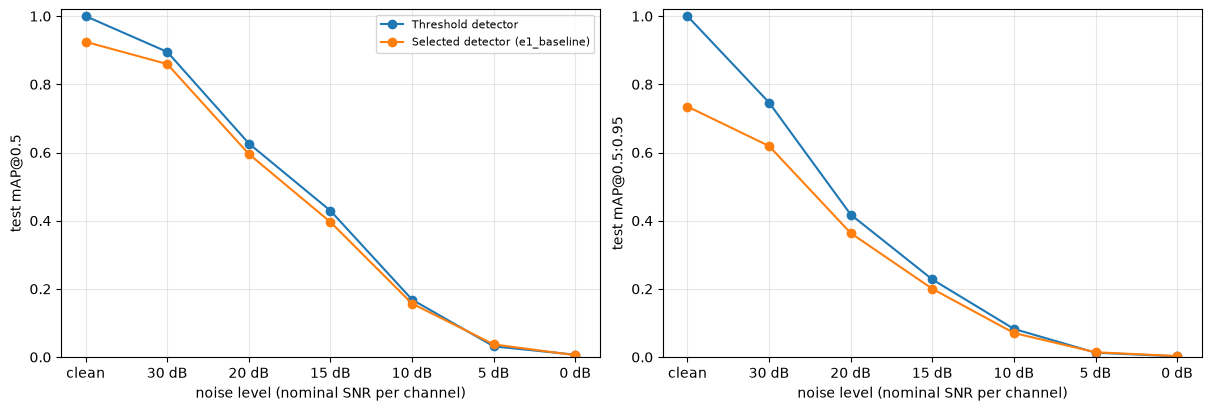

In [10]:
e4 = pd.read_csv(T / "e4_robustness.csv")
display(e4)
m = e4.set_index("model")[[c for c in e4.columns if c.startswith("map50_") and not c.startswith("map50_95")]]
display((100 * m.div(m["map50_clean"], axis=0)).round(1).rename(columns=lambda c: c.replace("map50_", "% of clean, ")))
plot_e4(e4, F / "e4_robustness.png")
plt.show()

Both methods lose performance at the same relative rate, so the trained detector is not more robust than the
threshold rule. The collapse already at a nominal 10 dB is explained by the small Laplacian: it removes the signal
shared by neighbouring electrodes but sums their independent noise. The effective SNR of the analysed signal
(noise restricted to 4–40 Hz) is computed below for every test subject.

In [11]:
from src.data import effective_snr_db, load_bandpassed_epochs

pcfg = load_config("configs/preprocess.yaml")
rows = []
for s in pcfg["subjects"]:
    _, _, x, ch = load_bandpassed_epochs(s, "E", pcfg)
    rows += [{"subject": s, "nominal_snr_db": snr, "effective_snr_db": effective_snr_db(x, ch, pcfg, snr)}
             for snr in (30, 20, 15, 10, 5, 0)]
eff = pd.DataFrame(rows)
eff.to_csv(T / "e4_effective_snr.csv", index=False)
eff.groupby("nominal_snr_db")["effective_snr_db"].agg(["mean", "min", "max"]).sort_index(ascending=False)

,mean,min,max
nominal_snr_db,,,
30,22.401,19.296,23.774
20,12.401,9.296,13.774
15,7.401,4.296,8.774
10,2.401,-0.704,3.774
5,-2.599,-5.704,-1.226
0,-7.599,-10.704,-6.226


## E5: decoding the motor imagery class per 5-trial group (test)

Detectors predict the class of the ERD box with the highest summed confidence (C4 → left hand, C3 → right hand,
Cz → feet, C5/C6 → tongue); groups without an ERD box count as wrong (*no decision*). CSP + LDA is trained per
subject on session T and averages its class probabilities over the same 5 trials. Chance is 25 % (κ = 0). Group
accuracy is not comparable with single-trial accuracies from the literature.

,run_id,method,split,n_groups,accuracy,kappa,no_decision_pct
0,e1_baseline,Selected detector (e1_baseline),test,1800.0,0.164,-0.115,67.278
1,threshold,Threshold detector,test,1800.0,0.203,-0.063,68.167
2,csp_lda,CSP + LDA,test,1800.0,0.718,0.624,0.000


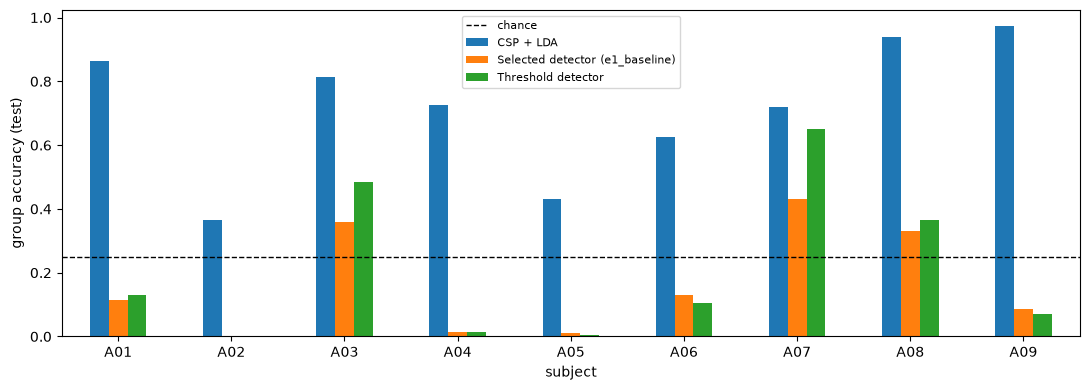

In [12]:
display(pd.read_csv(T / "e5_decoding.csv"))
per = pd.read_csv(T / "e5_decoding_per_subject.csv")
acc = per[per["subject"] != "all"].pivot(index="subject", columns="method", values="accuracy")
ax = acc.plot.bar(figsize=(11, 4), rot=0)
ax.axhline(0.25, color="k", ls="--", lw=1, label="chance")
ax.set_ylabel("group accuracy (test)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(F / "e5_decoding_by_subject.png", dpi=120)
plt.show()

The detectors make a decision for only about one third of the groups. The next cell separates *coverage*
(does the group contain an ERD box at all?) from *accuracy when a decision is made*.

In [13]:
rows = []
for run in ["e1_baseline", "e2_yolo11s", "threshold"]:
    d = decode_groups(load_predictions(run, "test")[0])
    decided = d[d["pred_class"] >= 0]
    row = {"run_id": run, "decided_pct": 100 * len(decided) / len(d),
           "acc_when_decided": (decided["pred_class"] == decided["true_class"]).mean()}
    row.update({f"decided_pct_{MI_CLASSES[c]}": 100 * (d[d["true_class"] == c]["pred_class"] >= 0).mean() for c in range(4)})
    rows.append(row)
cov = pd.DataFrame(rows)
cov.to_csv(T / "e5_coverage.csv", index=False)
cov

,run_id,decided_pct,acc_when_decided,decided_pct_left_hand,decided_pct_right_hand,decided_pct_feet,decided_pct_tongue
0,e1_baseline,32.722,0.501,58.889,46.222,20.667,5.111
1,e2_yolo11s,32.556,0.514,59.111,46.222,20.000,4.889
2,threshold,31.833,0.637,57.778,45.333,19.778,4.444


When an ERD box is present, its panel points to the right class in about half of the groups (two to three
times chance), but tongue and feet groups rarely contain an ERD box at all, in line with the grand averages
(tongue imagery produces mu ERS over the hand areas rather than ERD at C5/C6). CSP + LDA uses all channels and
the full covariance structure, so it decodes far better; the detector's value lies in localization and
interpretability, not in decoding accuracy.

## Per-subject detection (test)

In [14]:
psd = pd.read_csv(T / "per_subject_detection.csv")
psd = psd[psd["split"] == "test"]
display(psd.pivot(index="subject", columns="run_id", values="map50"))
psd[psd["run_id"] == "e1_baseline"][["subject", "n_images", "n_gt_boxes", "map50", "map50_95", "recall", "precision"]]

run_id,e1_baseline,e2_frcnn,e2_yolo11s
subject,,,
A01,0.925,0.720,0.905
A02,0.975,0.986,0.993
A03,0.840,0.710,0.857
A04,0.921,0.887,0.964
A05,0.792,0.379,0.906
A06,0.910,0.811,0.954
A07,0.963,0.892,0.953
A08,0.984,0.895,0.976
A09,0.911,0.786,0.946


,subject,n_images,n_gt_boxes,map50,map50_95,recall,precision
0,A01,200,102,0.925,0.654,0.912,0.788
1,A02,200,59,0.975,0.797,1.000,0.831
2,A03,200,220,0.840,0.619,0.968,0.859
3,A04,200,202,0.921,0.660,0.955,0.869
4,A05,200,24,0.792,0.563,1.000,0.828
5,A06,200,139,0.910,0.700,0.971,0.754
6,A07,200,675,0.963,0.786,0.982,0.857
7,A08,200,170,0.984,0.773,0.988,0.853
8,A09,200,360,0.911,0.775,0.956,0.699


Detection quality is fairly even across subjects, but the number of events is not: subjects with weak
sensorimotor modulation (A02, A05) contribute very few boxes, so their mAP rests on a handful of events.

## Answers

- **Q0** — Single-trial ERD cannot be labeled reliably: no rule beat phase-randomized surrogates by 3×. Averages of
  5 trials pass with 5–22× (`annotation.ipynb`).
- **Q1** — The baseline setting (SGD, lr0 1e-2, batch 16, imgsz 640, 100 epochs) was best on validation; the
  alternatives were within ≈ 0.02 mAP@0.5 except for the lower resolution, which hurts box precision.
- **Q2** — One-stage YOLO11 models clearly beat Faster R-CNN on these images; YOLO11n was selected on validation,
  YOLO11s is marginally better on the test session. Faster R-CNN confuses position-defined classes; one untested hypothesis is that
  its RoI classifier loses absolute position.
- **Q3** — Two classes instead of five give no improvement for `ERD_C4` / `ERD_C3`.
- **Q4** — The trained detector is not more robust to noise than the threshold rule; both degrade at the same
  relative rate, and the Laplacian makes nominal SNRs much harsher than they appear.
- **Q5** — As a decoder, detections are far below CSP + LDA because most groups contain no ERD box; when a box is
  present, its location is informative (about 2× chance).